# ICS2123 - Tarea 3 Código

### Celda 1: Importamos algunas librerías (NO MODIFICAR)

In [41]:
# Celda 1
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

### Celda 2: Parámetros (NO MODIFICAR)

In [42]:
# Celda 2
K = 1000  # Población total
porcentaje_inicial_infectados  = 0.05  # Porcentaje de la población que está expuesta
k = int(K*porcentaje_inicial_infectados)  # Población inicial de infectados, todos sintomáticos
alpha = 0.1  # Tasa de natalidad
beta_i = 0.4  # Tasa de transmisión de infectados sintomáticos
beta_a = 0.15  # Tasa de transmisión de infectados asintomáticos
sigma = 1/7  # Tasa de incubación (7 días en promedio)
p = 0.8  # Probabilidad de que un expuesto se vuelva sintomático
q = 0.15  # Probabilidad de hospitalización al enfermarse
gamma = 1/7  # Tasa aparición sintomas (7 días)
delta = 1/21  # Tasa de recuperación asintomáticos (21 días)
phi = 1/14  # Tasa de hospitalizacion (14 días)
r = 0.95  # Probabilidad de sobrevivir a la hospitalización
mu = 1/28 # Tasa de aislamiento a los recuperados (28 días)
s = 0.9 # Probabilidad de que se recupere completamente
estados_posibles = ["SUSCEPTIBLES", "EXPUESTOS",  "INFECTADOS_SINTOMATICOS", "INFECTADOS_ASINTOMATICOS", "HOSPITALIZADOS", "RECUPERADOS", "MUERTOS"]
estado_inicial = [K-k, 0, k, 0, 0, 0, 0]  # Estado inicial de la población
t_simulacion = 365*1  # Tiempo de simulación (días)


parametros = {}
parametros["alpha"] = alpha
parametros["beta_i"] = beta_i
parametros["beta_a"] = beta_a
parametros["sigma"] = sigma
parametros["p"] = p
parametros["q"] = q
parametros["gamma"] = gamma
parametros["delta"] = delta
parametros["phi"] = phi
parametros["r"] = r
parametros["mu"] = mu
parametros["s"] = s
parametros["estados_posibles"] = estados_posibles
parametros["estado_inicial"] = estado_inicial
parametros["t_simulacion"] = t_simulacion
parametros["semilla"] = 2123

## Inciso b)

### Celda 3: Crear función para simular la CMTC (MODIFICAR)

In [43]:
def simular_cmtc(parametros):
    np.random.seed(parametros["semilla"])
    random.seed(parametros["semilla"])
    
    alpha = parametros["alpha"]
    beta_i = parametros["beta_i"]
    beta_a = parametros["beta_a"]
    sigma = parametros["sigma"]
    p = parametros["p"]
    q = parametros["q"]
    gamma = parametros["gamma"]
    delta = parametros["delta"]
    phi = parametros["phi"]
    mu = parametros["mu"]
    r = parametros["r"]
    s = parametros["s"]
    estado_inicial = parametros["estado_inicial"].copy()
    t_simulacion = parametros["t_simulacion"]

    tiempo_actual = 0
    estado_actual = estado_inicial.copy()
    nacimientos_totales = 0
    
    tiempos = [tiempo_actual]
    estados = [estado_actual.copy()]
    
    while tiempo_actual < t_simulacion:
        S, E, I, A, H, R, M = estado_actual
        N = S + E + I + A + H
        
        if N == 0:
            break
        
        # Calcular tasas de transición
        # 1. Nacimiento (solo si hay al menos una persona viva)
        tasa_nacimiento = alpha * (N > 0)
        
        # 2. Infección de susceptibles (S -> E)
        tasa_S_E= S * (beta_i * I / N + beta_a * A / N) if N > 0 else 0
        
        # 3.1 Desarrollo de síntomas (E -> I)
        tasa_E_I = sigma * p * E
        
        # 3.2 Desarrollo de  asintomáticos (E -> A)
        tasa_E_A = sigma * (1 - p) * E
        
        # 4.1 Recuperación de infectados sintomáticos (I -> S)
        tasa_I_S = gamma * (1 - q) * I
        
        # 4.2 hospitalización de infectados sintomáticos (I -> H)
        tasa_I_H = gamma * q * I
        
        # 5. Recuperación de asintomáticos (A -> S)
        tasa_A_S = delta * A
        
        # 6.1 Recuperación de hospitalizados (H -> R)
        tasa_H_R = phi * r * H
        
        # 6.2 muerte de hospitalizados (H -> M)
        tasa_H_M = phi * (1 - r) * H

        # 7.1 Recuperación completa (R -> S )
        tasa_R_S = mu * s * R
        
        # 7.2 Recaída de recuperados (R -> H)
        tasa_R_h = mu * (1 - s)* R
        
        # Tasa total de transición
        tasa_total = (tasa_nacimiento + tasa_S_E + tasa_E_I + tasa_E_A + tasa_I_S + tasa_I_H + tasa_A_S + tasa_H_R + tasa_H_M + tasa_R_S + tasa_R_h)
        
        if tasa_total == 0:
            break
        
        tiempo_hasta_transicion = np.random.exponential(1/tasa_total)
        tiempo_actual += tiempo_hasta_transicion
        
        if tiempo_actual > t_simulacion:
            break
        
        u = np.random.random() * tasa_total
        acumulado = 0
        acumulado += tasa_nacimiento
        
        if u < acumulado:
            estado_actual[0] += 1
            nacimientos_totales += 1
        else:
            acumulado += tasa_S_E
            if u < acumulado:
                estado_actual[0] -= 1
                estado_actual[1] += 1
            else:
                acumulado += tasa_E_I
                if u < acumulado:
                    estado_actual[1] -= 1
                    estado_actual[2] += 1
                else:
                    acumulado += tasa_E_A
                    if u < acumulado:
                        estado_actual[1] -= 1
                        estado_actual[3] += 1
                    else:
                        acumulado += tasa_I_S
                        if u < acumulado:
                            estado_actual[2] -= 1
                            estado_actual[0] += 1
                        else:
                            acumulado += tasa_I_H
                            if u < acumulado:
                                estado_actual[2] -= 1
                                estado_actual[4] += 1
                            else:
                                acumulado += tasa_A_S
                                if u < acumulado:
                                    estado_actual[3] -= 1
                                    estado_actual[0] += 1
                                else:
                                    acumulado += tasa_H_R
                                    if u < acumulado:
                                        estado_actual[4] -= 1
                                        estado_actual[5] += 1
                                    else:
                                        acumulado += tasa_H_M
                                        if u < acumulado:
                                            estado_actual[4] -= 1
                                            estado_actual[6] += 1
                                        else:
                                            acumulado += tasa_R_S
                                            if u < acumulado:
                                                estado_actual[5] -= 1
                                                estado_actual[0] += 1
                                            else:
                                                estado_actual[5] -= 1
                                                estado_actual[4] += 1
        
        tiempos.append(tiempo_actual)
        estados.append(estado_actual.copy())
    
    tiempos = np.array(tiempos)
    estados = np.array(estados)
    poblacion_viva = np.sum(estados[:, :-1], axis=1)
    
    resultados = {
        "tiempos": tiempos,
        "estados": estados,
        "poblacion_viva": poblacion_viva,
        "estado_final": estados[-1],
        "nacimientos_totales": nacimientos_totales
    }
    
    return resultados

resultados = simular_cmtc(parametros)

ESTADO FINAL DESPUES DE 365 días:
    SUSCEPTIBLES: 284
    EXPUESTOS: 211
    INFECTADOS_SINTOMATICOS: 180
    INFECTADOS_ASINTOMATICOS: 129
    HOSPITALIZADOS: 66
    RECUPERADOS: 107
    MUERTOS: 64
    POBLACIÓN TOTAL VIVA: 977
    NACIMIENTOS TOTALES: 41


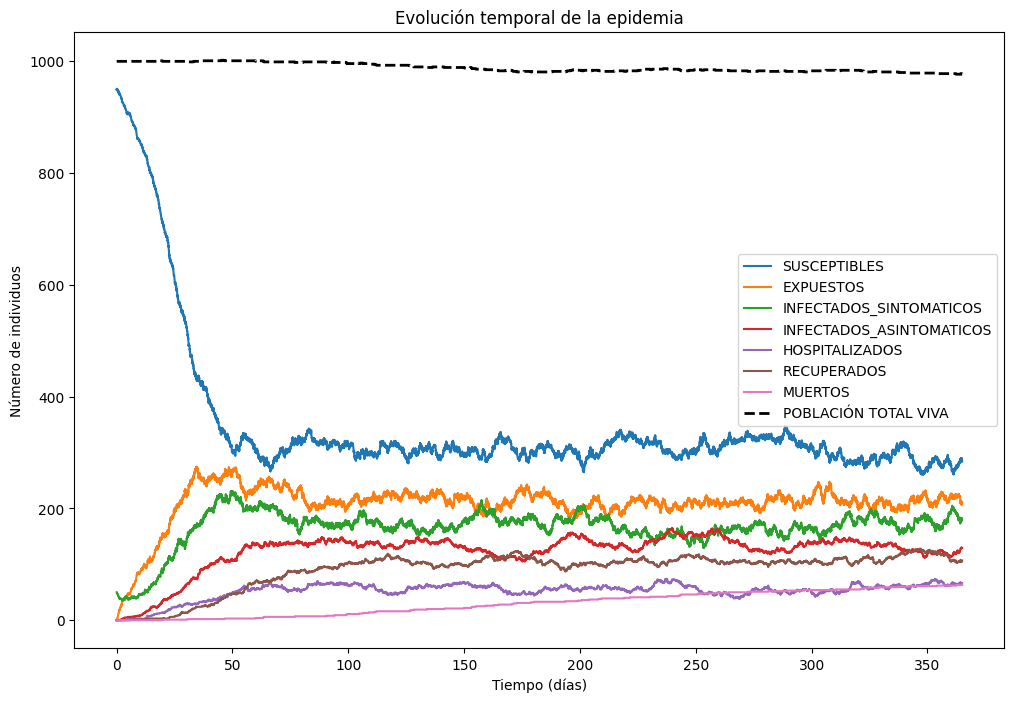

In [44]:
def visualizar_resultados(resultados, estados_posibles, t_simulacion):
    
    tiempos = resultados["tiempos"]
    estados = resultados["estados"]
    poblacion_viva = resultados["poblacion_viva"]
    nacimientos_totales = resultados["nacimientos_totales"]
    
    plt.figure(figsize=(12, 8))
    
    for i, estado_nombre in enumerate(estados_posibles):
        plt.plot(tiempos, estados[:, i], label=estado_nombre)
    
    plt.plot(tiempos, poblacion_viva, 'k--', linewidth=2, label='POBLACIÓN TOTAL VIVA')
    plt.xlabel('Tiempo (días)')
    plt.ylabel('Número de individuos')
    plt.title('Evolución temporal de la epidemia')
    plt.legend()
    plt.grid(False)
    
    print(f"ESTADO FINAL DESPUES DE {t_simulacion} días:")
    for i, estado_nombre in enumerate(estados_posibles):
        print(f"    {estado_nombre}: {estados[-1, i]}")
    print(f"    POBLACIÓN TOTAL VIVA: {poblacion_viva[-1]}")
    print(f"    NACIMIENTOS TOTALES: {nacimientos_totales}")
    
visualizar_resultados(resultados, parametros["estados_posibles"], parametros["t_simulacion"])

## Inciso c)

### Celda 4: Parámetros (NO MODIFICAR)

In [45]:
# Celda 4
numero_simulaciones = 100
parametros["t_simulacion"] = 365*10
lista_semillas = [i for i in range(numero_simulaciones)]

# Nota: Son 100 simulaciones, pero el tiempo de simulación es de 10 años (3650 días), manteniendo el resto de los parámetros constantes del inciso anterior.
# Por cada simulación, se debe cambiar la semilla, para que cada simulación sea diferente. Para eso, cambiar parametros["semilla"] = i, con i el número de la simulación.

### Celda 5: Acá deben ejecutar sus simulaciones y posteriores análisis

Completadas 10 simulaciones
Completadas 20 simulaciones
Completadas 30 simulaciones
Completadas 40 simulaciones
Completadas 50 simulaciones
Completadas 60 simulaciones
Completadas 70 simulaciones
Completadas 80 simulaciones
Completadas 90 simulaciones
Completadas 100 simulaciones

Estadísticas finales después de 10 años:
Estado                    Promedio   IC 95% Inferior IC 95% Superior
--------------------------------------------------
SUSCEPTIBLES              228.90     225.59          232.21         
EXPUESTOS                 159.83     157.69          161.97         
INFECTADOS_SINTOMATICOS   126.65     124.33          128.97         
INFECTADOS_ASINTOMATICOS  97.24      95.46           99.02          
HOSPITALIZADOS            42.32      40.87           43.77          
RECUPERADOS               79.22      77.38           81.06          
MUERTOS                   630.20     626.29          634.11         
POBLACIÓN TOTAL VIVA      734.16     729.47          738.85         


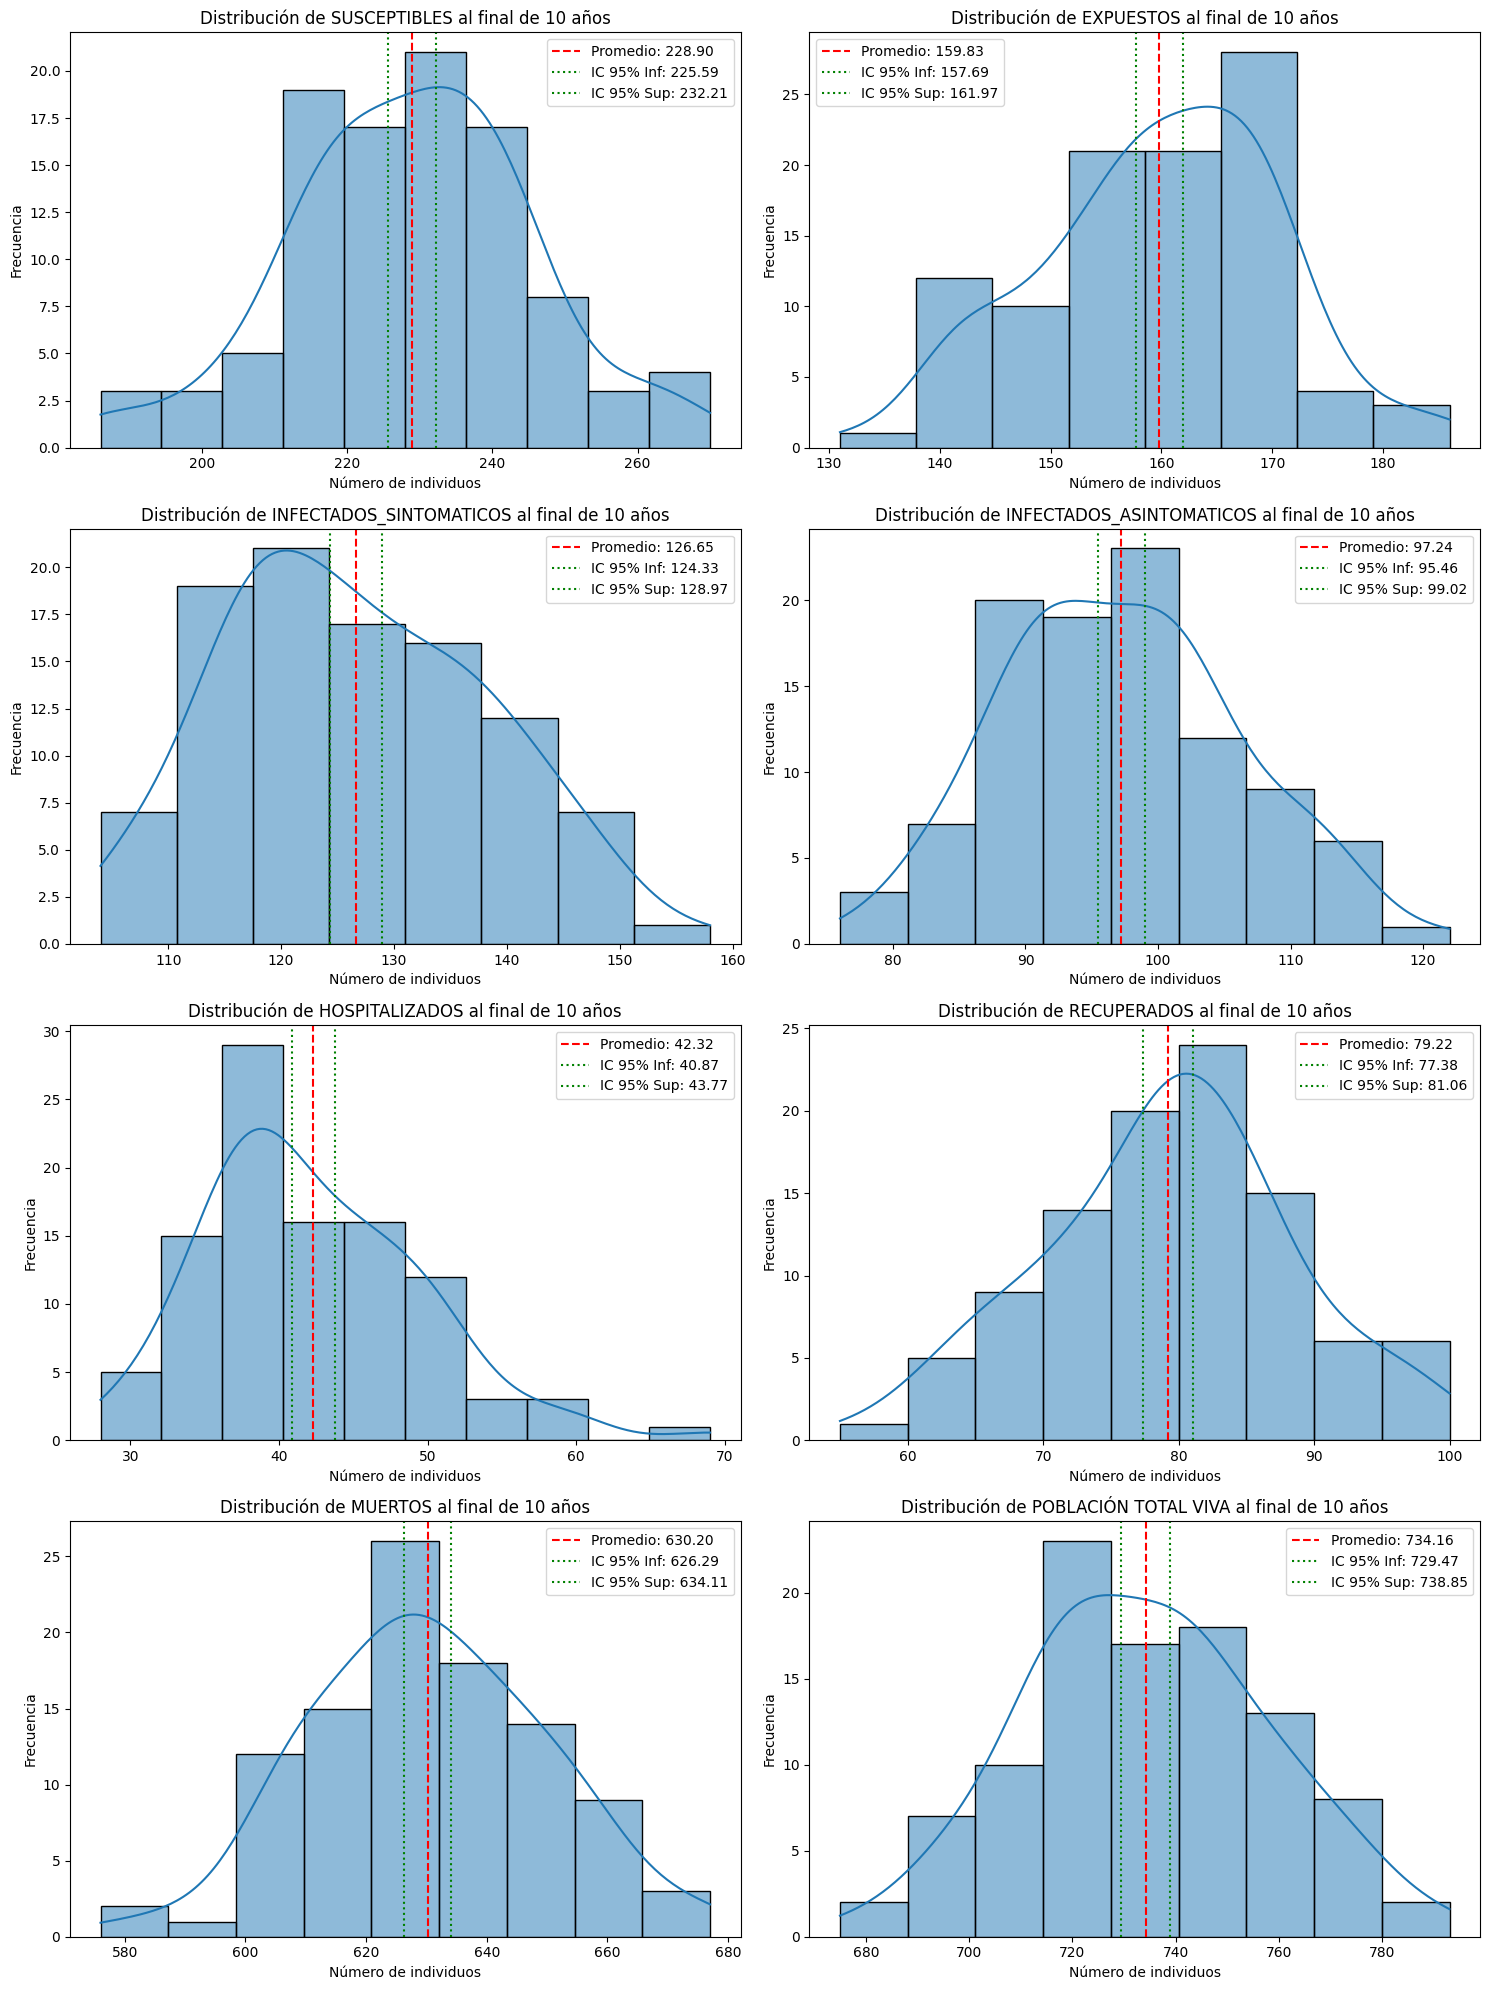

In [46]:
def analizar_simulaciones_multiples(parametros, numero_simulaciones=100, tiempo_simulacion_años=10, lista_semillas=None):
    parametros_copia = parametros.copy()
    parametros_copia["t_simulacion"] = 365 * tiempo_simulacion_años
    
    if lista_semillas is None:
        lista_semillas = [i for i in range(numero_simulaciones)]
    
    resultados_finales = []
    
    for i, semilla in enumerate(lista_semillas[:numero_simulaciones]):
        parametros_copia["semilla"] = semilla
        resultado = simular_cmtc(parametros_copia)
        resultados_finales.append(resultado["estado_final"])
        
        if (i+1) % 10 == 0:
            print(f"Completadas {i+1} simulaciones")
    
    resultados_finales = np.array(resultados_finales)
    poblacion_viva_final = np.sum(resultados_finales[:, :-1], axis=1)
    todos_resultados = np.column_stack((resultados_finales, poblacion_viva_final))
    estados_posibles = parametros_copia["estados_posibles"]
    nombres_estados = estados_posibles + ["POBLACIÓN TOTAL VIVA"]
    
    print(f"\nEstadísticas finales después de {tiempo_simulacion_años} años:")
    print("=" * 50)
    print(f"{'Estado':<25} {'Promedio':<10} {'IC 95% Inferior':<15} {'IC 95% Superior':<15}")
    print("-" * 50)
    
    fig, axs = plt.subplots(4, 2, figsize=(15, 20))
    axs = axs.flatten()
    
    estadisticas = {}
    
    # Para cada estado, calcular estadísticas y crear histograma
    for i, estado_nombre in enumerate(nombres_estados):
        valores = todos_resultados[:, i]
        promedio = np.mean(valores)
        error_estandar = stats.sem(valores)
        intervalo_confianza = stats.t.interval(0.95, len(valores)-1, loc=promedio, scale=error_estandar)
        
        estadisticas[estado_nombre] = {
            "promedio": promedio,
            "ic_inferior": intervalo_confianza[0],
            "ic_superior": intervalo_confianza[1],
            "valores": valores
        }
        
        print(f"{estado_nombre:<25} {promedio:<10.2f} {intervalo_confianza[0]:<15.2f} {intervalo_confianza[1]:<15.2f}")
        
        if i < len(axs):  
            ax = axs[i]
            sns.histplot(valores, kde=True, ax=ax)
            ax.set_title(f'Distribución de {estado_nombre} al final de {tiempo_simulacion_años} años')
            ax.set_xlabel('Número de individuos')
            ax.set_ylabel('Frecuencia')
            ax.axvline(promedio, color='r', linestyle='--', label=f'Promedio: {promedio:.2f}')
            ax.axvline(intervalo_confianza[0], color='g', linestyle=':', label=f'IC 95% Inf: {intervalo_confianza[0]:.2f}')
            ax.axvline(intervalo_confianza[1], color='g', linestyle=':', label=f'IC 95% Sup: {intervalo_confianza[1]:.2f}')
            
            ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    return {
        "resultados_finales": resultados_finales,
        "poblacion_viva_final": poblacion_viva_final,
        "todos_resultados": todos_resultados,
        "estadisticas": estadisticas
    }
    
resultados_analisis = analizar_simulaciones_multiples(parametros)

## Inciso d)

### Celda 6: Parámetros Alternativa 1 (NO MODIFICAR)

In [47]:
# Celda 6
# Alternativa 1: Aumentar a 1.2 veces la tasa de natilidad
parametros_alternativos_1 = parametros.copy()
parametros_alternativos_1["alpha"] = 1.2*parametros["alpha"]
parametros_alternativos_1["t_simulacion"] = 365*10
lista_semillas = [i for i in range(numero_simulaciones)]

# Nota: Son 100 simulaciones, pero el tiempo de simulación es de 10 años (3650 días), manteniendo el resto de los parámetros constantes del inciso anterior.
# Por cada simulación, se debe cambiar la semilla, para que cada simulación sea diferente. Para eso, cambiar parametros["semilla"] = i, con i el número de la simulación.
# (Es el mismo procedimiento que el inciso anterior, pero ahora se cambia la tasa de natalidad a 1.2 veces la original).

Completadas 10 simulaciones
Completadas 20 simulaciones
Completadas 30 simulaciones
Completadas 40 simulaciones
Completadas 50 simulaciones
Completadas 60 simulaciones
Completadas 70 simulaciones
Completadas 80 simulaciones
Completadas 90 simulaciones
Completadas 100 simulaciones

Estadísticas finales después de 10 años:
Estado                    Promedio   IC 95% Inferior IC 95% Superior
--------------------------------------------------
SUSCEPTIBLES              243.84     240.25          247.43         
EXPUESTOS                 171.04     168.65          173.43         
INFECTADOS_SINTOMATICOS   135.26     132.54          137.98         
INFECTADOS_ASINTOMATICOS  101.88     99.88           103.88         
HOSPITALIZADOS            45.21      43.98           46.44          
RECUPERADOS               88.35      86.63           90.07          
MUERTOS                   651.69     647.71          655.67         
POBLACIÓN TOTAL VIVA      785.58     780.69          790.47         


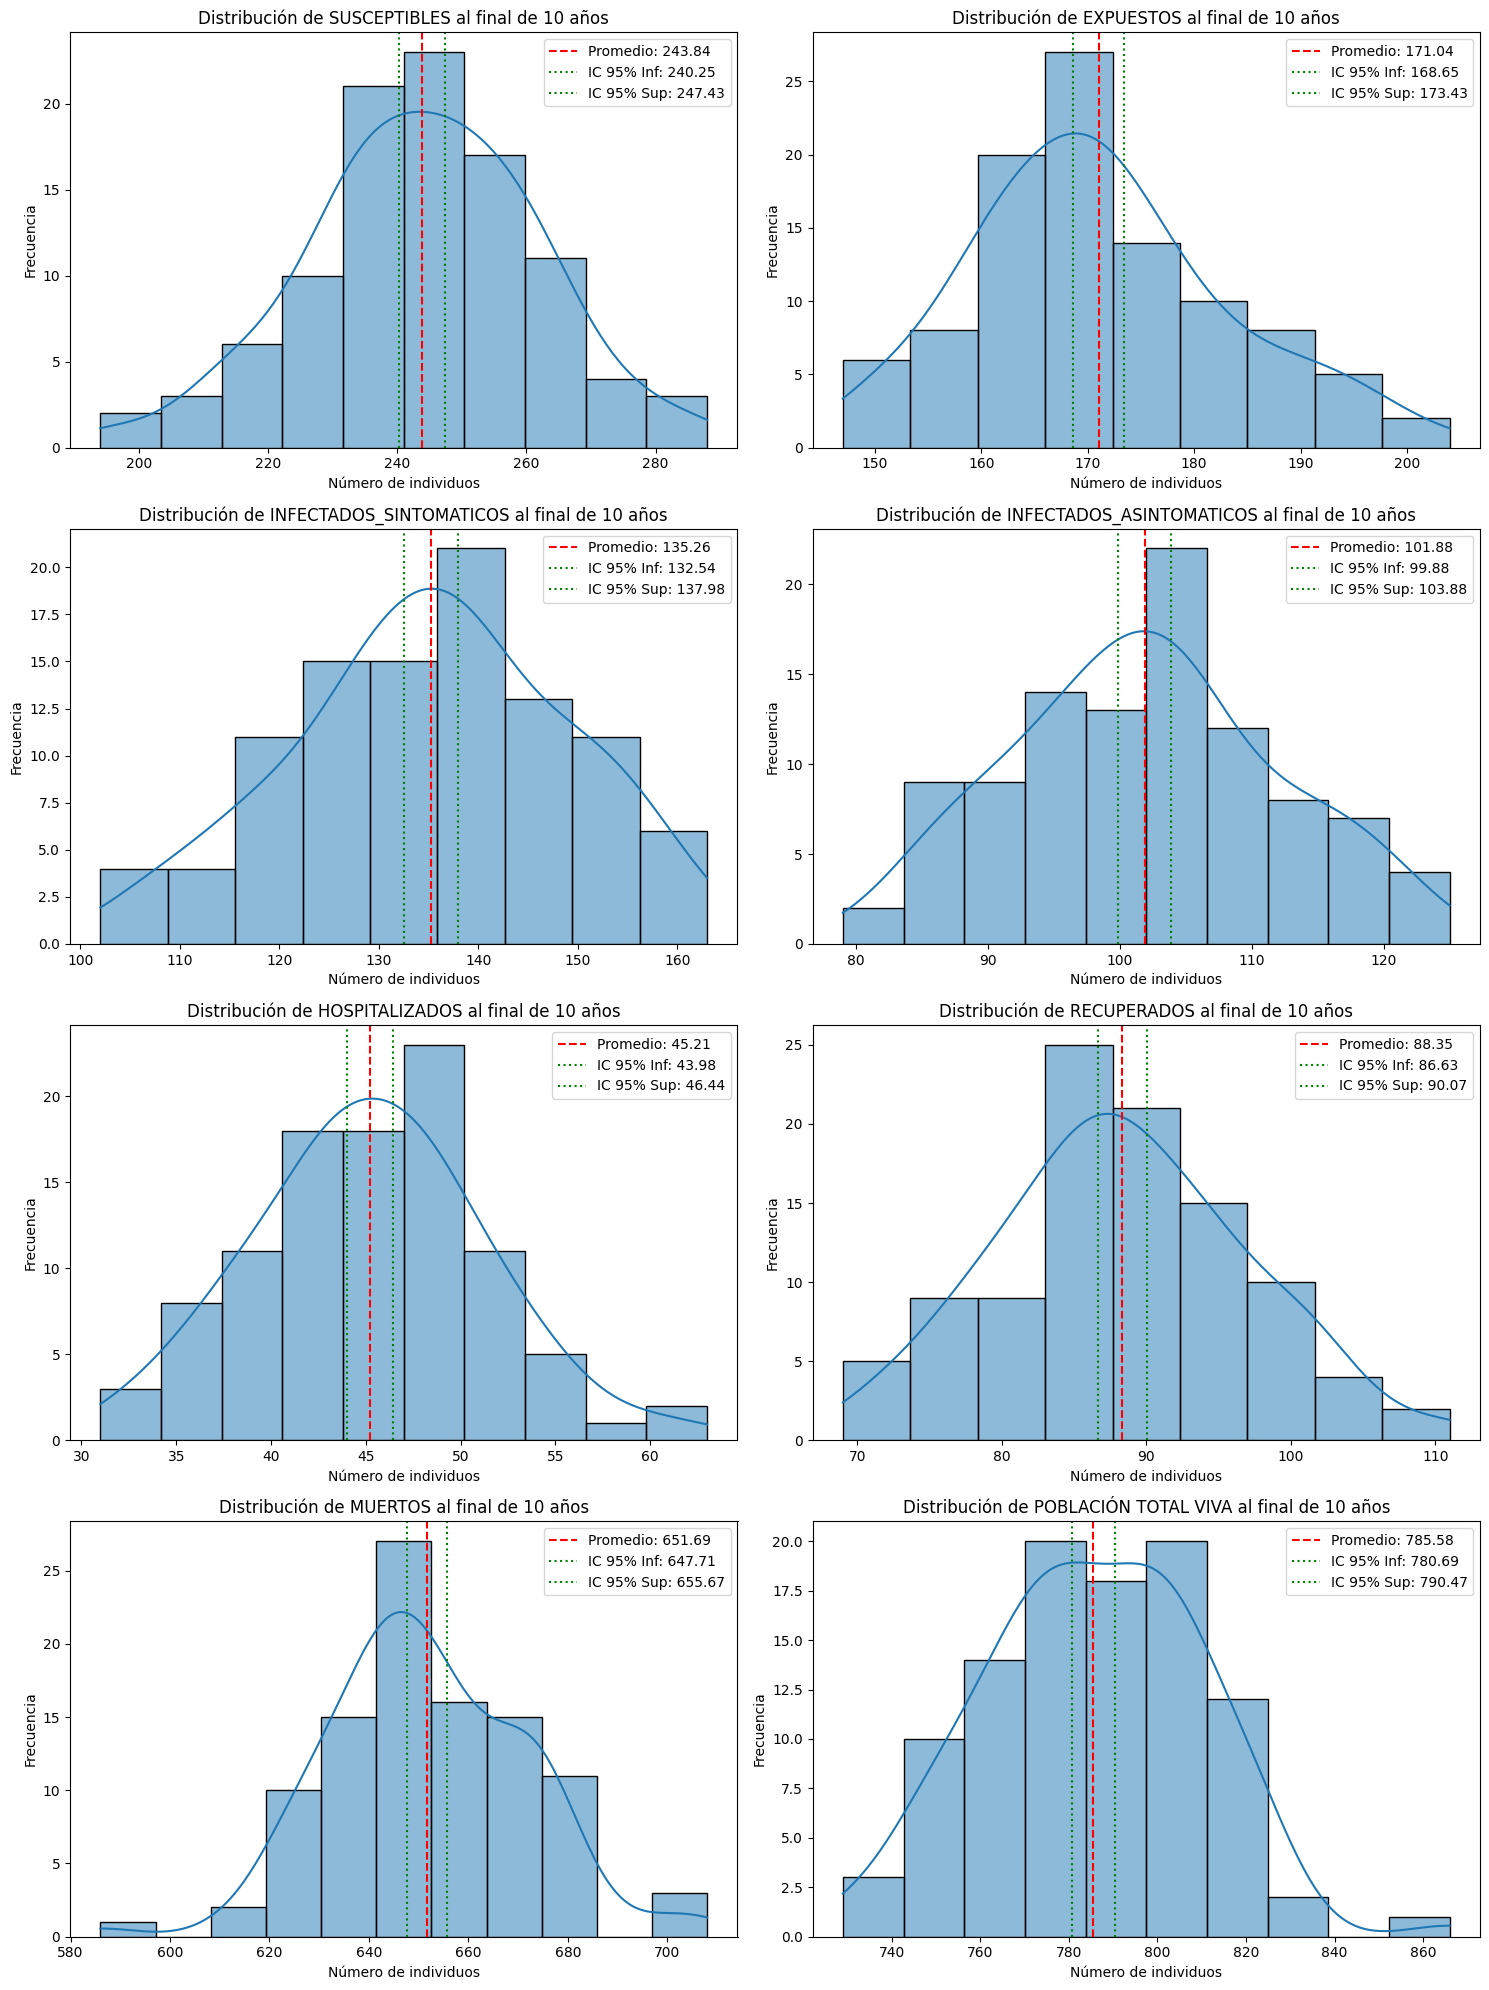

In [48]:
resultados_analisis = analizar_simulaciones_multiples(parametros_alternativos_1)

### Celda 7: Parámetros Alternativa 2 (NO MODIFICAR)

In [49]:
# Celda 7
# Alternativa 2: Disminución tiempo de detccion sintomas y disminución probabilidad de hospitalización
parametros_alternativos_2 = parametros.copy()
parametros_alternativos_2["gamma"] = 2*parametros["gamma"]
parametros_alternativos_2["q"] = parametros["q"]/2
parametros_alternativos_2["t_simulacion"] = 365*10
lista_semillas = [i for i in range(numero_simulaciones)]

# Nota: Son 100 simulaciones, pero el tiempo de simulación es de 10 años (3650 días), manteniendo el resto de los parámetros constantes del inciso anterior.
# Por cada simulación, se debe cambiar la semilla, para que cada simulación sea diferente. Para eso, cambiar parametros["semilla"] = i, con i el número de la simulación.
# (Es el mismo procedimiento que el inciso anterior, pero ahora se cambia la tasa de detección de sintomas a 2 veces, 0.5 la probabilidad de requerir hospitalización veces la original).


Completadas 10 simulaciones
Completadas 20 simulaciones
Completadas 30 simulaciones
Completadas 40 simulaciones
Completadas 50 simulaciones
Completadas 60 simulaciones
Completadas 70 simulaciones
Completadas 80 simulaciones
Completadas 90 simulaciones
Completadas 100 simulaciones

Estadísticas finales después de 10 años:
Estado                    Promedio   IC 95% Inferior IC 95% Superior
--------------------------------------------------
SUSCEPTIBLES              561.54     556.54          566.54         
EXPUESTOS                 198.00     195.18          200.82         
INFECTADOS_SINTOMATICOS   78.91      76.90           80.92          
INFECTADOS_ASINTOMATICOS  119.03     116.51          121.55         
HOSPITALIZADOS            25.48      24.67           26.29          
RECUPERADOS               49.72      48.29           51.15          
MUERTOS                   330.46     327.22          333.70         
POBLACIÓN TOTAL VIVA      1032.68    1028.59         1036.77        


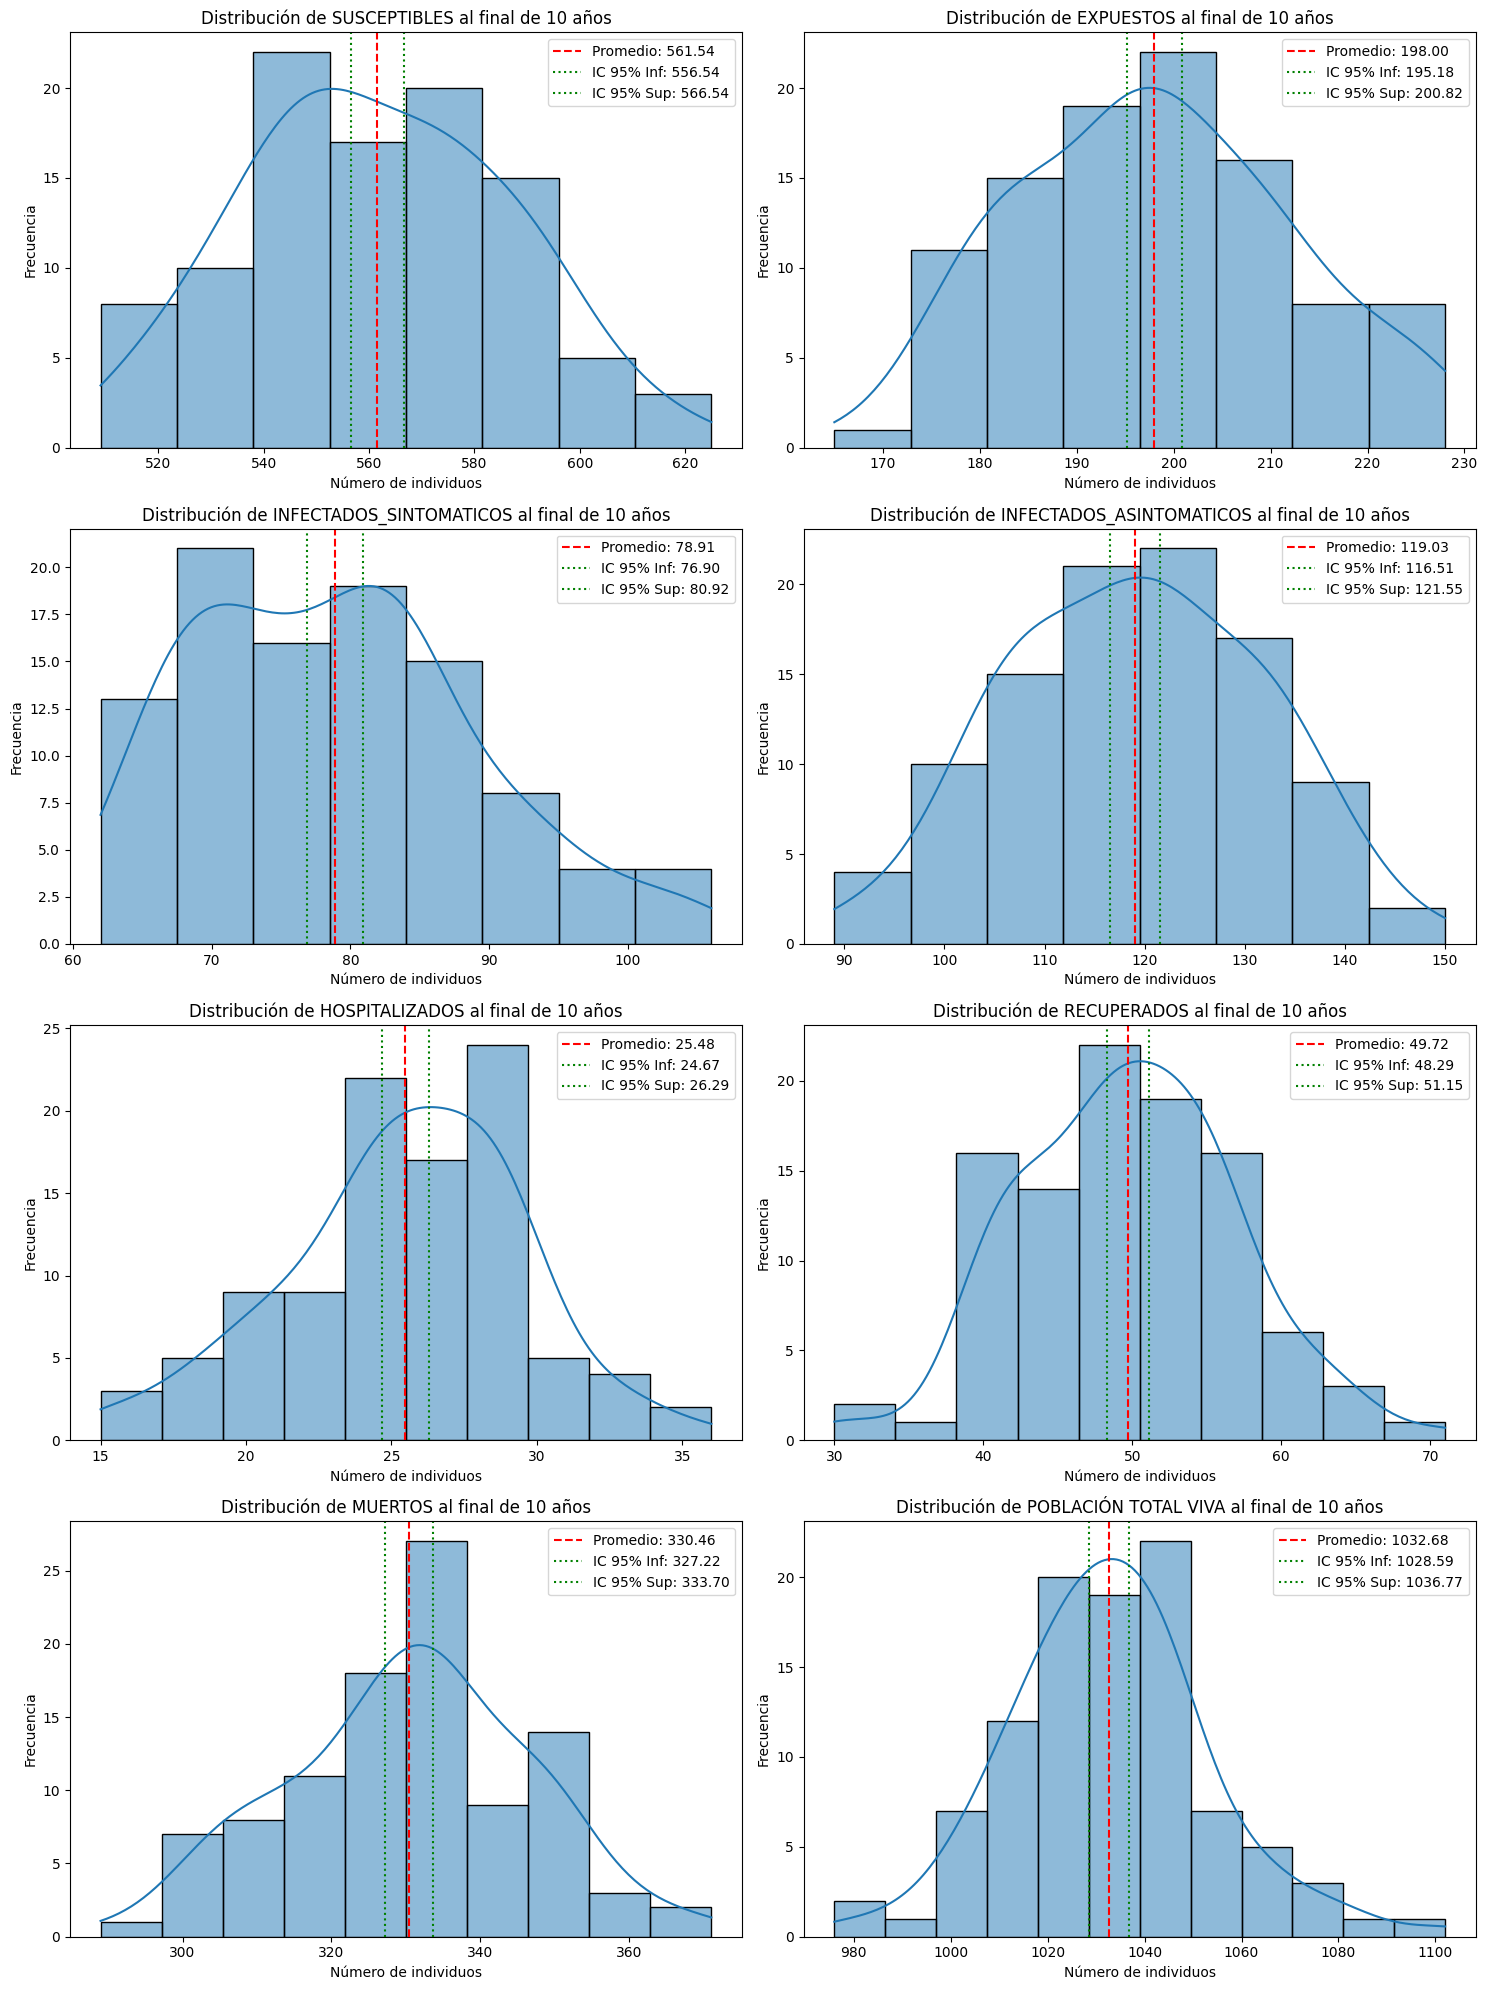

In [50]:
resultados_analisis = analizar_simulaciones_multiples(parametros_alternativos_2)

### Celda 8: Parámetros Alternativa 3 (NO MODIFICAR)

In [51]:
# Celda 8
# Alternativa 3: disminución tiempo de hospitalizacion, aumento probabilidad de recuperación
parametros_alternativos_3 = parametros.copy()
parametros_alternativos_3["phi"] = 2*parametros["phi"]
parametros_alternativos_3["r"] = parametros["r"]*1.03
parametros_alternativos_2["t_simulacion"] = 365*10
lista_semillas = [i for i in range(numero_simulaciones)]

# Nota: Son 100 simulaciones, pero el tiempo de simulación es de 10 años (3650 días), manteniendo el resto de los parámetros constantes del inciso anterior.
# Por cada simulación, se debe cambiar la semilla, para que cada simulación sea diferente. Para eso, cambiar parametros["semilla"] = i, con i el número de la simulación.
# (Es el mismo procedimiento que el inciso anterior, pero ahora con 2 veces la tasa de estadía del hospital y 1.03 la probabilidad de recuperación).

Completadas 10 simulaciones
Completadas 20 simulaciones
Completadas 30 simulaciones
Completadas 40 simulaciones
Completadas 50 simulaciones
Completadas 60 simulaciones
Completadas 70 simulaciones
Completadas 80 simulaciones
Completadas 90 simulaciones
Completadas 100 simulaciones

Estadísticas finales después de 10 años:
Estado                    Promedio   IC 95% Inferior IC 95% Superior
--------------------------------------------------
SUSCEPTIBLES              317.30     313.19          321.41         
EXPUESTOS                 230.51     228.05          232.97         
INFECTADOS_SINTOMATICOS   183.09     180.57          185.61         
INFECTADOS_ASINTOMATICOS  141.52     139.16          143.88         
HOSPITALIZADOS            30.64      29.67           31.61          
RECUPERADOS               121.92     119.88          123.96         
MUERTOS                   339.17     336.11          342.23         
POBLACIÓN TOTAL VIVA      1024.98    1020.40         1029.56        


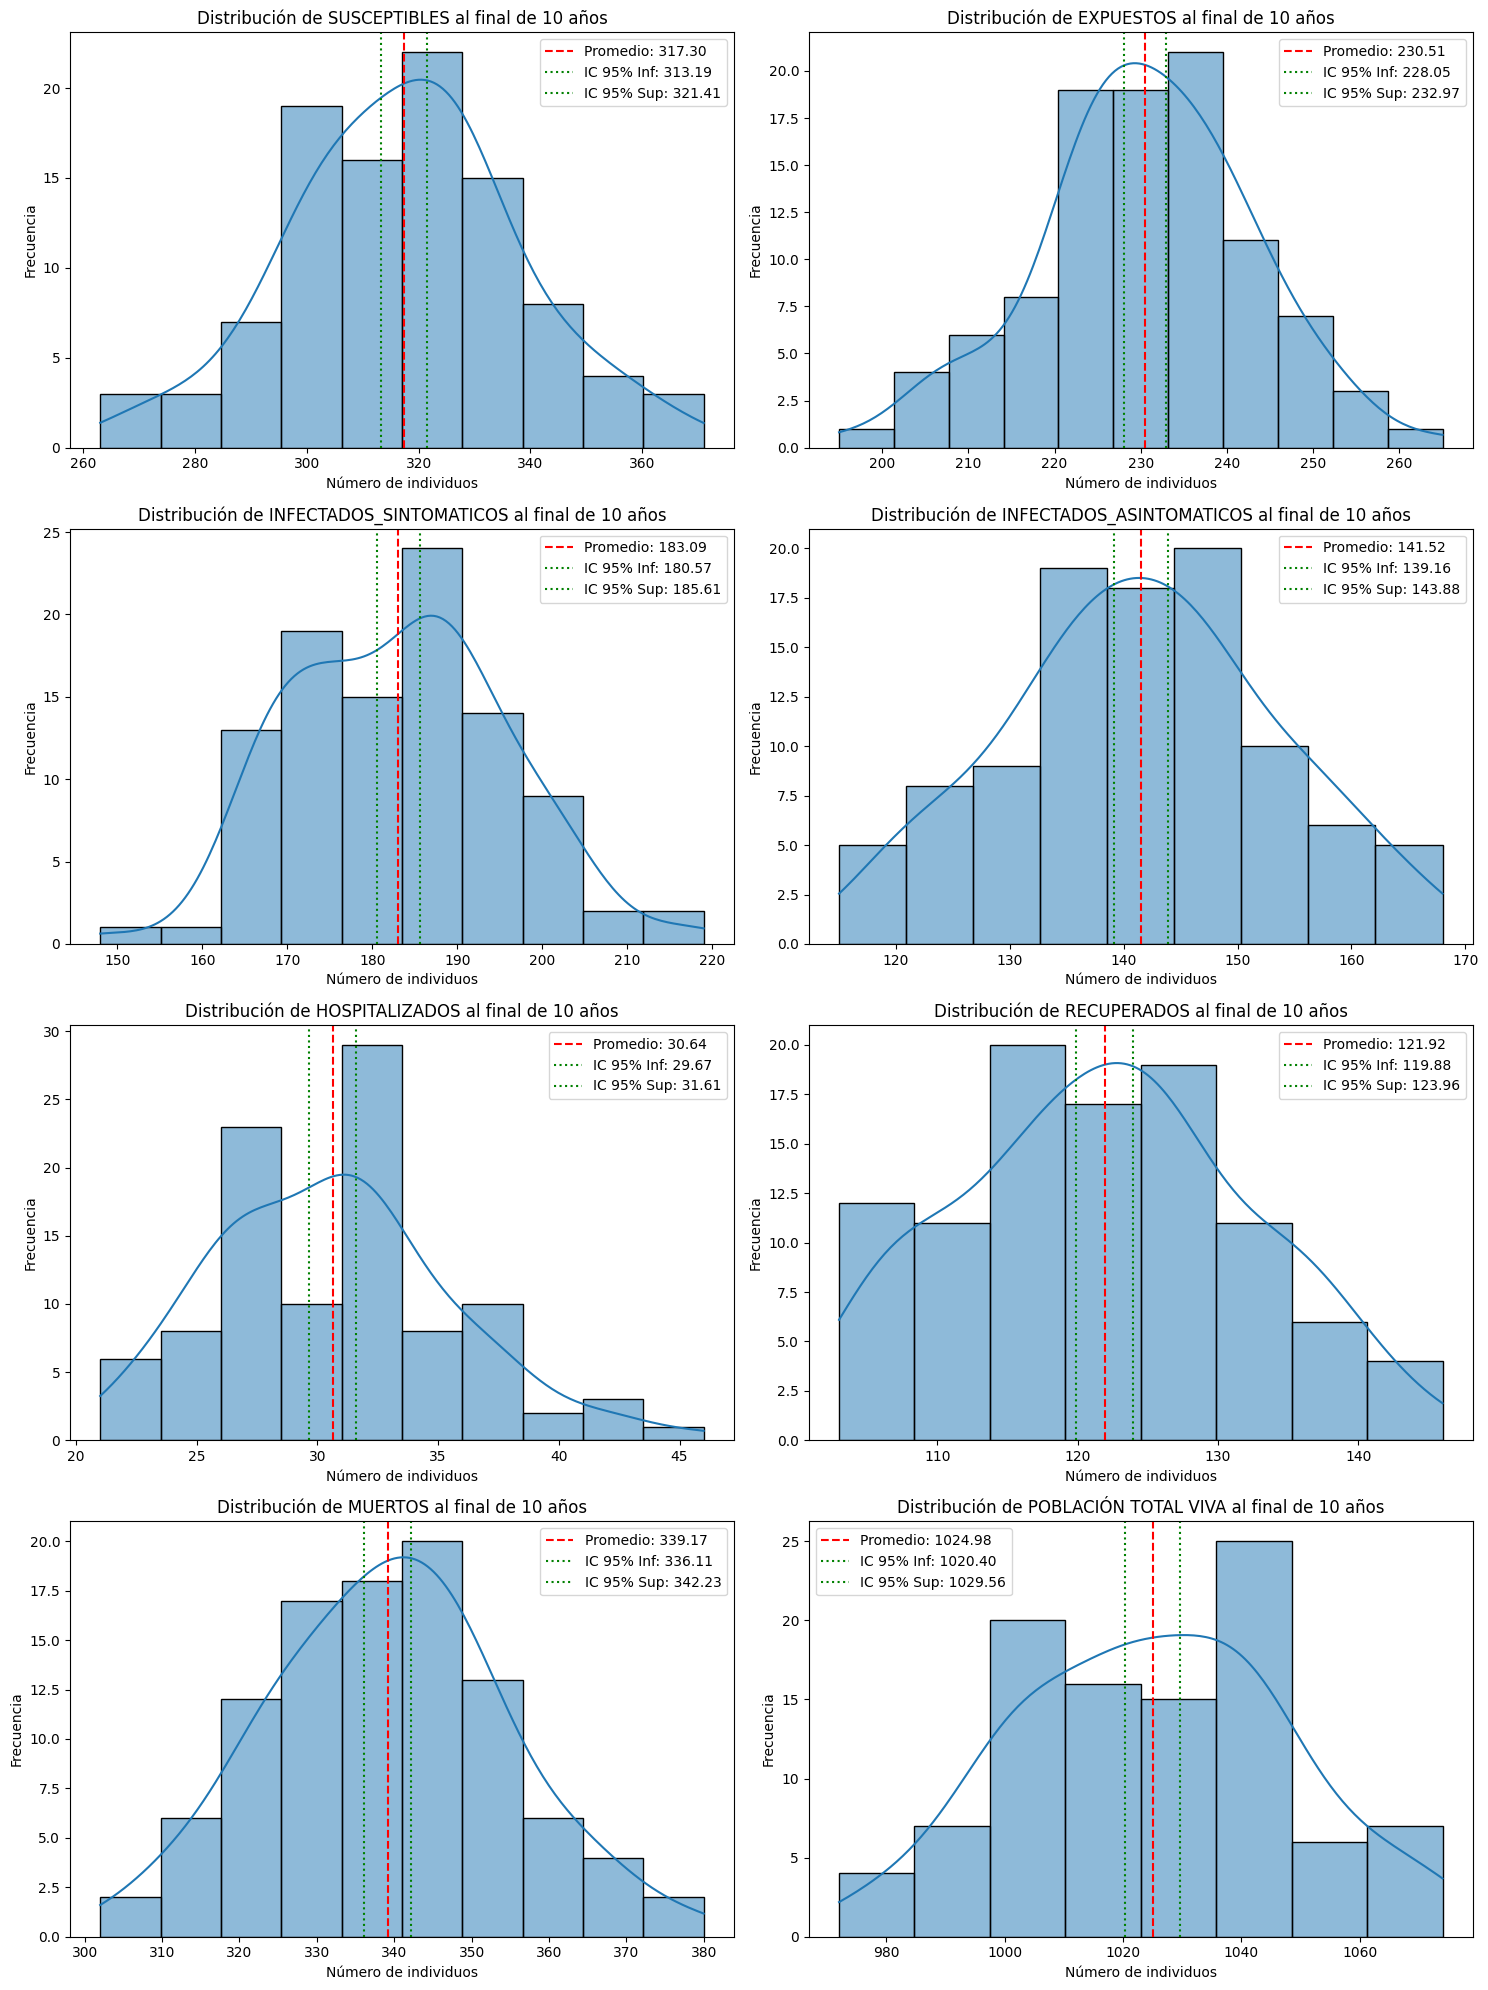

In [52]:
resultados_analisis = analizar_simulaciones_multiples(parametros_alternativos_3)